In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
X, y=make_moons(n_samples=300, noise=0.06, random_state=42)
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaler.fit(X)
X_scaled=scaler.transform(X)
dbscan=DBSCAN()
kumeler=dbscan.fit_predict(X_scaled)

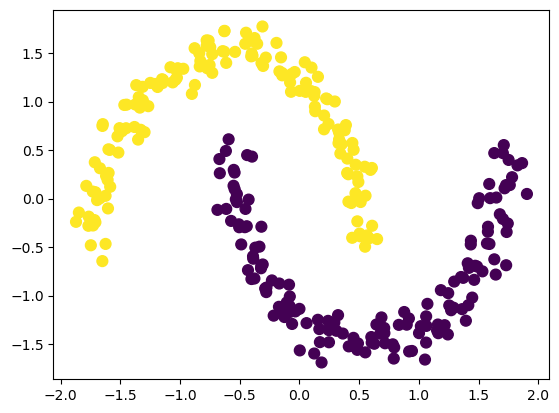

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=kumeler, s=60)

### EnsembleLearning

from sklearn import datasets
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

iris = datasets.load_iris()
X, y = iris.data[:, 1:3], iris.target

clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(n_estimators=50, random_state=1)
clf3 = GaussianNB()

eclf = VotingClassifier(
        estimators=[('lr', clf1), ('rf', clf2), ('gnb', clf3)],
        voting='hard')

for clf, label in zip([clf1, clf2, clf3, eclf], ['Logisitic Regression', 'Random Forest', 'naive bayes', 'Ensemble']):
    scores = cross_val_score(clf, X, y, scoring='accuracy', cv=5)
    print=("Accuracy: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), label))

In [13]:
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from itertools import product
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score

iris = datasets.load_iris()
X = iris.data[:, [0, 2]]
y = iris.target

clf1 = DecisionTreeClassifier(max_depth=4)
clf2 = KNeighborsClassifier(n_neighbors=7)
clf3 = SVC(kernel='rbf', probability=True)
eclf = VotingClassifier(estimators=[('dt', clf1), ('knn', clf2), ('svc', clf3)],
                       voting='soft', weights=[2, 1, 2])

clf1 = clf1.fit(X, y)
clf2 = clf2.fit(X, y)
clf3 = clf3.fit(X, y)
eclf = eclf.fit(X, y)

for clf, label in zip([clf1, clf2, clf3, eclf], ['DecisionTree', 'KNN', 'SVM', 'Ensemble']):
    
    scores = cross_val_score(clf, X, y, scoring='accuracy')
    print=("Accuracy: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), label))